#### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import struct

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
from torch.optim.lr_scheduler import ReduceLROnPlateau

#### Useful functions/classes

In [2]:
### Reads block files in input_dir up to a maximum time step (max), flattens blocks to be 1x, and
### stores them in a nested list of format all_data[spatial_location[time_step[flattened_block_index]]]: 4608x443x512
def process_data(input_dir, max, block_dim, component):

    num_blocks = int((256/block_dim) * (96/block_dim) * (96/block_dim))
    
    # Set up nested list to store data
    all_data = []
    for l in range(num_blocks):
        all_data.append([])
        for t in range(74, max):
            all_data[l].append([])
    
    for t in range(74, max): # iterate over each time step
        filename = input_dir + str(t) + "-" + str(block_dim) + "-" + str(component) + ".raw"
        with open(filename, "rb") as file: 
            for l in range(num_blocks): # iterate over each location
                data = [] 
                for i in range(block_dim**3): # iterate through the block
                    all_data[l][t-74].append(struct.unpack('<f', file.read(4))[0])
        if (t-73) % 10 == 0:
            print("Processed data from first",str(t-73),"time steps")

    return all_data
    
    
### Creates torch tensors of input/target pairs for use in the LSTM. For each target (each timestep), 
### creates an input sequence of the seq_radius steps before and after that target. Output from 
### process_data can be directly input as obs to this function.
def to_sequences(seq_radius, obs):
    # input storage
    x = []
    # output storage
    y = []
    for l in range(len(obs)): # iterate over each location
        lobs = obs[l]
        for i in range(seq_radius, len(lobs) - seq_radius): # iterate over each possible input/target pair
            window = lobs[(i - seq_radius):i] + lobs[i + 1:(i + seq_radius + 1)] # define inputs at i
            mid_window = lobs[i] # define output at i
            window = np.array(window) # convert to np arrays
            x.append(window)
            y.append(mid_window)
    x = np.array(x)
    y = np.array(y)
    return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


class CombustionData(Dataset):
    def __init__(self, X_full, y_full):
        super().__init__()
        self.X_full = X_full
        self.y_full = y_full

    def __len__(self):
        return len(self.X_full)

    def __getitem__(self, idx):
        input = self.X_full[idx]
        output = self.y_full[idx]
        return input, output

#### Hyperparameters

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on", device)
lr = 3e-4
batch_size = 256
epochs = 100

Running on cuda


#### Data preprocessing

In [4]:
data = process_data("volumes8-6/", 517, 8, 6)
x, y = to_sequences(1, data)
print(x.shape)
print(y.shape)

# Scale the input to be between -1 and 1
xmin = x.min()
xmax = x.max()
ymin = y.min()
ymax = y.max()
xnormal = (x - xmin) / (xmax - xmin)
ynormal = (y - ymin) / (ymax - ymin)

# Initialize the dataset, split into train and validate sets, and create loaders
dataset = CombustionData(xnormal, ynormal)
train_data, val_data = random_split(dataset, [0.9, 0.1])
train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(dataset=val_data, batch_size=batch_size, shuffle=False)

Processed data from first 10 time steps
Processed data from first 20 time steps
Processed data from first 30 time steps
Processed data from first 40 time steps
Processed data from first 50 time steps
Processed data from first 60 time steps
Processed data from first 70 time steps
Processed data from first 80 time steps
Processed data from first 90 time steps
Processed data from first 100 time steps
Processed data from first 110 time steps
Processed data from first 120 time steps
Processed data from first 130 time steps
Processed data from first 140 time steps
Processed data from first 150 time steps
Processed data from first 160 time steps
Processed data from first 170 time steps
Processed data from first 180 time steps
Processed data from first 190 time steps
Processed data from first 200 time steps
Processed data from first 210 time steps
Processed data from first 220 time steps
Processed data from first 230 time steps
Processed data from first 240 time steps
Processed data from first

#### Model initialization

In [5]:
# Define model
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, 
                            num_layers=num_layers, batch_first=True)
        self.dropout = nn.Dropout(0.05)
        #self.fc1 = nn.Linear(hidden_size, 1024)
        self.fc2 = nn.Linear(hidden_size, input_size)

    def forward(self, x):
        x, _ = self.lstm(x)
        x = self.dropout(x[:, -1, :])
        #x = self.fc1(x)
        x = self.fc2(x)
        return x

# Initialize model
model = LSTMModel(512, 1024, 3).to(device)

#### Train model

In [ ]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)
# scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=3, verbose=True)

early_stop_count = 0
min_val_loss = float('inf')

train_hist = []
val_hist = []

for epoch in range(epochs):
    # Train model
    model.train()
    train_losses = []
    for batch in train_loader:
        x_batch, y_batch = batch
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        train_losses.append(loss.item())
        loss.backward()
        optimizer.step()
    train_loss = np.mean(train_losses)
    train_hist.append(train_loss)

    # Validate model
    model.eval()
    val_losses = []
    with torch.no_grad():
        for batch in test_loader:
            x_batch, y_batch = batch
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            val_losses.append(loss.item())
    val_loss = np.mean(val_losses)
    val_hist.append(val_loss)
    #scheduler.step(val_loss)

    # Check for early stopping
    if val_loss < min_val_loss:
        min_val_loss = val_loss
        early_stop_count = 0
    else:
        early_stop_count += 1
 
    if early_stop_count >= 5:
        print("Early stopping!")
        break
    print(f"Epoch {epoch + 1}/{epochs}: Training Loss = {train_loss:.8f}, Validation Loss = {val_loss:.8f}")

Epoch 1/100: Training Loss = 0.00141032, Validation Loss = 0.00046042
Epoch 2/100: Training Loss = 0.00042311, Validation Loss = 0.00029713
Epoch 3/100: Training Loss = 0.00034130, Validation Loss = 0.00025523
Epoch 4/100: Training Loss = 0.00025213, Validation Loss = 0.00020486
Epoch 5/100: Training Loss = 0.00022170, Validation Loss = 0.00018853
Epoch 6/100: Training Loss = 0.00020417, Validation Loss = 0.00015915
Epoch 7/100: Training Loss = 0.00018297, Validation Loss = 0.00016161
Epoch 8/100: Training Loss = 0.00017259, Validation Loss = 0.00015359
Epoch 9/100: Training Loss = 0.00016432, Validation Loss = 0.00014166


## Plot loss

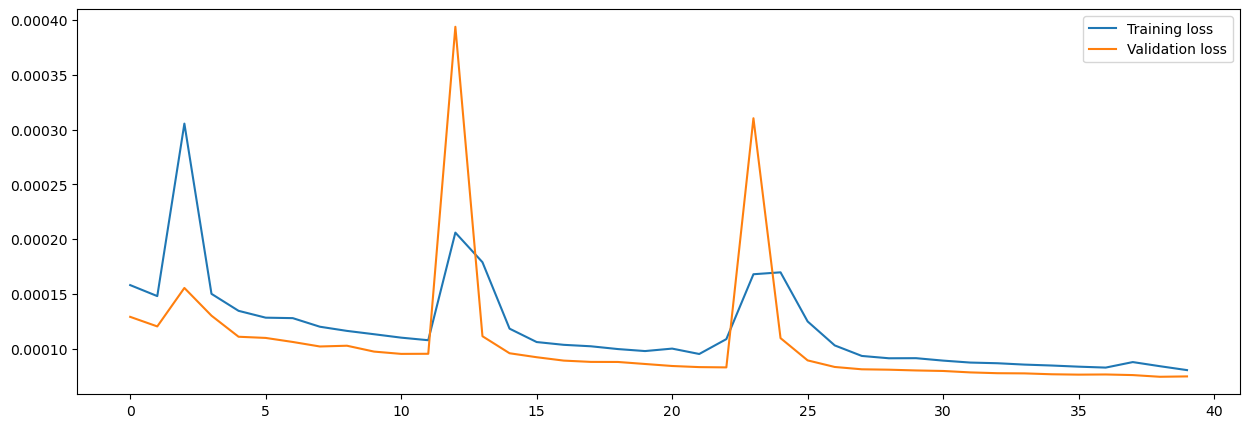

In [8]:
plt.figure(figsize=(15,5))
plt.plot(range(40), train_hist, label='Training loss')
plt.plot(range(40), val_hist, label='Validation loss')
plt.legend()

#### Generate a whole timestep using the trained model

In [9]:
### Uses a trained model to generate level 0 output for a given time step based on the 
### seq_radius time steps around it
def generate_output(obs, model, step, block_dim, seq_radius):

    # Translate step from filename to actual position
    step = step - 74

    num_blocks = int((256/block_dim) * (96/block_dim) * (96/block_dim))

    # Assemble the necessary inputs around the desired step for each location in the volume

    preds = [] # Ultimately a 4608x1x512

    for l in range(num_blocks):
        lobs = obs[l]
        past = lobs[(step - seq_radius):step]
        future = lobs[step + 1:(step + seq_radius + 1)]
        input = past + future
        input = np.array(input)
        input = torch.tensor(input, dtype=torch.float32).to(device)
        input = input[None, :, :]
        normal_input = (input - xmin) / (xmax - xmin)
        
        # Generate a prediction for each loaction in the known output using the model
        pred = model(normal_input)
        pred = pred.cpu().detach().numpy()
        preds.append(pred)

    # Unpack preds and reshape to be one volume
    preds = np.array(preds)
    preds = torch.tensor(preds, dtype=torch.float32).squeeze()
    preds = preds * (xmax - xmin) + xmin
    print(preds.shape)
    
    x_steps = int(256/block_dim)
    y_steps = int(96/block_dim)
    z_steps = int(96/block_dim)

    prediction = np.empty((256, 96, 96))
    block_num = 0

    for k in range(z_steps):
        for j in range(y_steps):
            for i in range(x_steps):
                x_lo = int(i * block_dim)
                y_lo = int(j * block_dim)
                z_lo = int(k * block_dim)
                block_idx = 0
                for z in range(block_dim):
                    for y in range(block_dim):
                        for x in range(block_dim):
                            prediction[x_lo + x][y_lo + y][z_lo + z] = preds[block_num][block_idx]
                            block_idx += 1
                block_num += 1

    return prediction
                

# Retrieve and assemble the known output
def get_output(obs, step, block_dim):

    # Translate step from filename to actual position
    step = step - 74
    
    num_blocks = int((256/block_dim) * (96/block_dim) * (96/block_dim))

    reals = []

    for l in range(num_blocks):
        lobs = obs[l]
        real = lobs[step]
        real = np.array(real)
        reals.append(real)

    reals = np.array(reals)
    reals = torch.tensor(reals, dtype=torch.float32)
    print(reals.shape)

    x_steps = int(256/block_dim)
    y_steps = int(96/block_dim)
    z_steps = int(96/block_dim)

    actual = np.empty((256, 96, 96))
    block_num = 0

    for k in range(z_steps):
        for j in range(y_steps):
            for i in range(x_steps):
                x_lo = int(i * block_dim)
                y_lo = int(j * block_dim)
                z_lo = int(k * block_dim)
                block_idx = 0
                for z in range(block_dim):
                    for y in range(block_dim):
                        for x in range(block_dim):
                            actual[x_lo + x][y_lo + y][z_lo + z] = reals[block_num][block_idx]
                            block_idx += 1
                block_num += 1

    return actual


prediction = generate_output(data, model, 100, 8, 4)
print(prediction[222][40][40])

actual = get_output(data, 100, 8)
print(actual[222][40][40])

torch.Size([4608, 512])
1043.510986328125
torch.Size([4608, 512])
1043.9810791015625


#### Calculate metrics on the known and predicted output

In [12]:
def calc_mse(actual, predicted):
    
    xdim = actual.shape[0]
    ydim = actual.shape[1]
    zdim = actual.shape[2]

    sum = 0

    for k in range(zdim):
        for j in range(ydim):
            for i in range(xdim):
                sq = (actual[i][j][k] - predicted[i][j][k])**2
                sum += sq

    mse = sum / (xdim * ydim * zdim)

    return mse

rmse = (calc_mse(actual, prediction))**0.5
var = torch.var(y)
print(rmse)
r2 = 1 - (rmse**2)/(var**2)
print(r2)

18.81608871841919
tensor(1.0000)


#### Write prediction and actual to be visualized

In [21]:
def write_to_visualize(volume, path, out_file):
    filename = path + out_file
    with open(filename, "wb") as file:
        volume.tofile(file)

delta = actual - prediction

write_to_visualize(prediction, "toVisualize/", "prediction.raw")
write_to_visualize(actual, "toVisualize/", "actual.raw")
write_to_visualize(delta, "toVisualize/", "delta.raw")